# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch1 2026-2027 — Major Project

**Dataset:** `seasonal_agriculture_performance_dataset.csv`
**Goal:** Investigate how agricultural performance (yield, production, cost, revenue, profit)
and the underlying environmental/resource factors vary across the three cropping seasons
in India — **Kharif, Rabi and Zaid** — and derive evidence-based insights and recommendations.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


In [3]:
from google.colab import files
uploaded = files.upload()  # a "Choose Files" button will appear — pick the CSV

import pandas as pd
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print("Shape:", df.shape)
df.head()


Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv
Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


Distribution of Yield (Tonnes/Hectare)


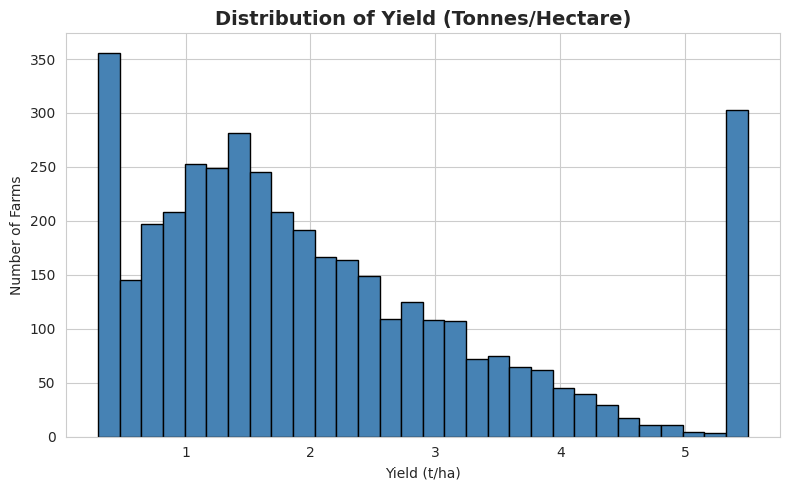

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_clean["Yield_Tonnes_Ha"], bins=30, color="steelblue", edgecolor="black")
ax.set_title("Distribution of Yield (Tonnes/Hectare)")
ax.set_xlabel("Yield (t/ha)")
ax.set_ylabel("Number of Farms")
plt.tight_layout()
plt.show()

Rainfall vs Yield by Season-scatter plot


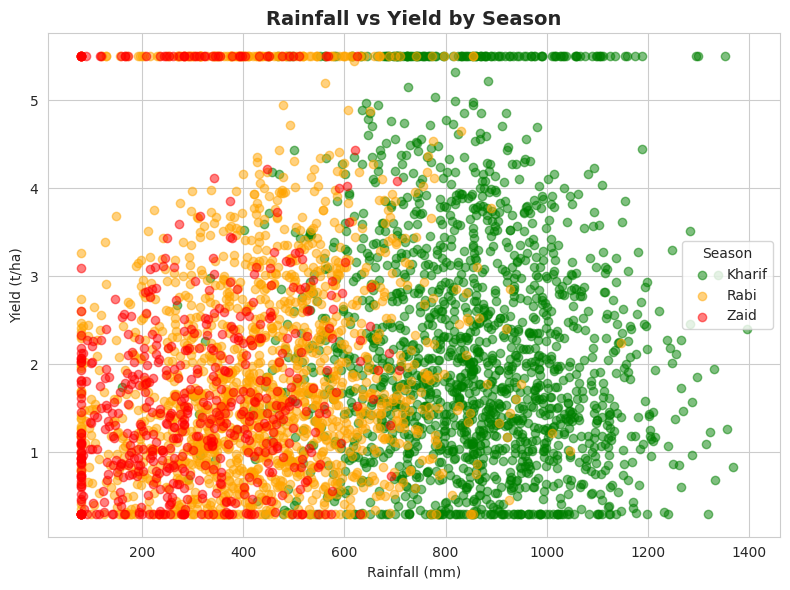

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {"Kharif": "green", "Rabi": "orange", "Zaid": "red"}
for season, group in df_clean.groupby("Season"):
    ax.scatter(group["Rainfall_mm"], group["Yield_Tonnes_Ha"],
               label=season, alpha=0.5, color=colors[season])
ax.set_title("Rainfall vs Yield by Season")
ax.set_xlabel("Rainfall (mm)")
ax.set_ylabel("Yield (t/ha)")
ax.legend(title="Season")
plt.tight_layout()
plt.show()

Proportion of Farm Records by Season-pie chart


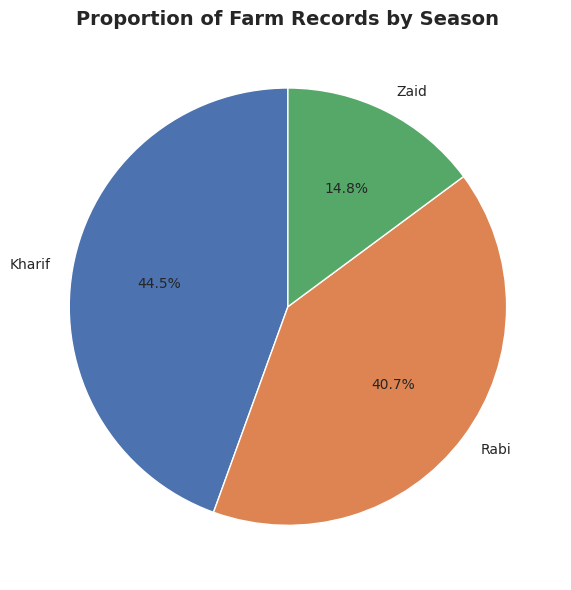

In [37]:
season_counts = df_clean["Season"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(season_counts, labels=season_counts.index, autopct="%1.1f%%",
       colors=["#4C72B0", "#DD8452", "#55A868"], startangle=90)
ax.set_title("Proportion of Farm Records by Season")
plt.tight_layout()
plt.show()

Average Profit by Season (with Value Labels)

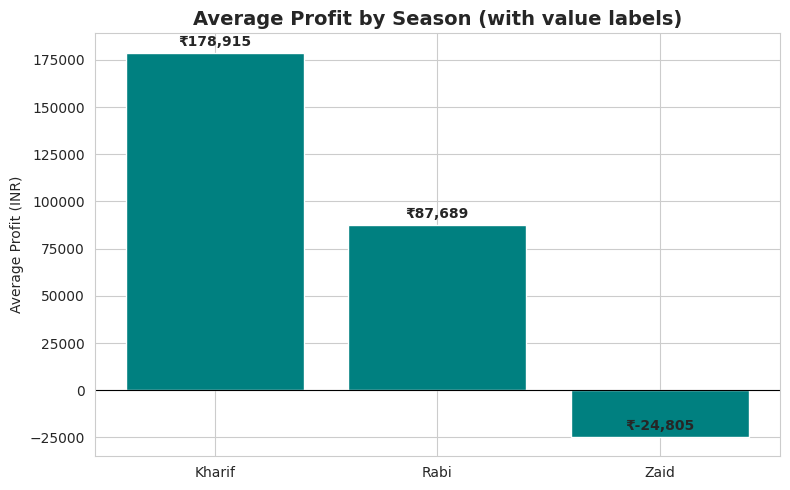

In [38]:
season_profit = df_clean.groupby("Season")["Profit_INR"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(season_profit.index, season_profit.values, color="teal")

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"₹{height:,.0f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=10, fontweight="bold")

ax.set_title("Average Profit by Season (with value labels)")
ax.set_ylabel("Average Profit (INR)")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

Temperature vs Profit — Highlighting the Top-Performing Farm


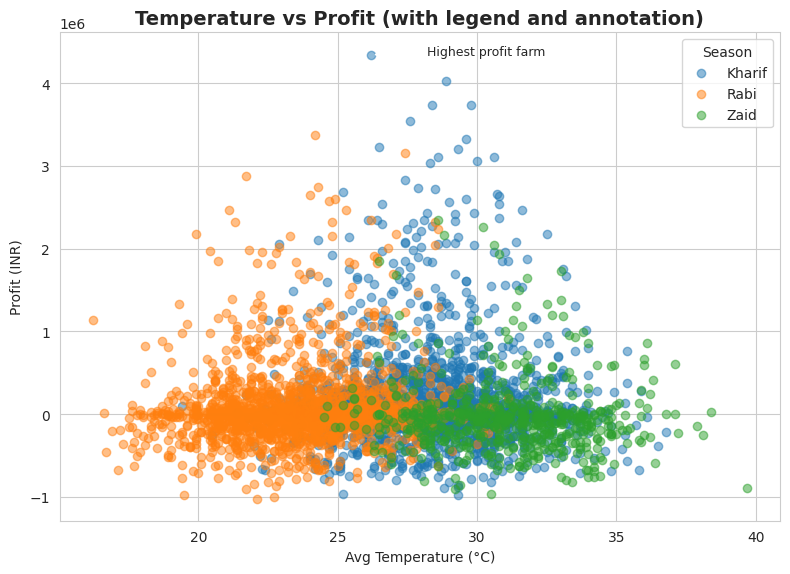

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))
for season, group in df_clean.groupby("Season"):
    ax.scatter(group["Avg_Temperature_C"], group["Profit_INR"], label=season, alpha=0.5)

ax.legend(title="Season", loc="upper right")

# annotate the single most profitable farm
top_farm = df_clean.loc[df_clean["Profit_INR"].idxmax()]
ax.annotate("Highest profit farm",
            xy=(top_farm["Avg_Temperature_C"], top_farm["Profit_INR"]),
            xytext=(top_farm["Avg_Temperature_C"] + 2, top_farm["Profit_INR"]),
            arrowprops=dict(facecolor="black", arrowstyle="->"),
            fontsize=9)

ax.set_title("Temperature vs Profit (with legend and annotation)")
ax.set_xlabel("Avg Temperature (°C)")
ax.set_ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

Distribution of Key Environmental Variables  with individual subplot titles Rainfall Distribution and Temperature Distribution

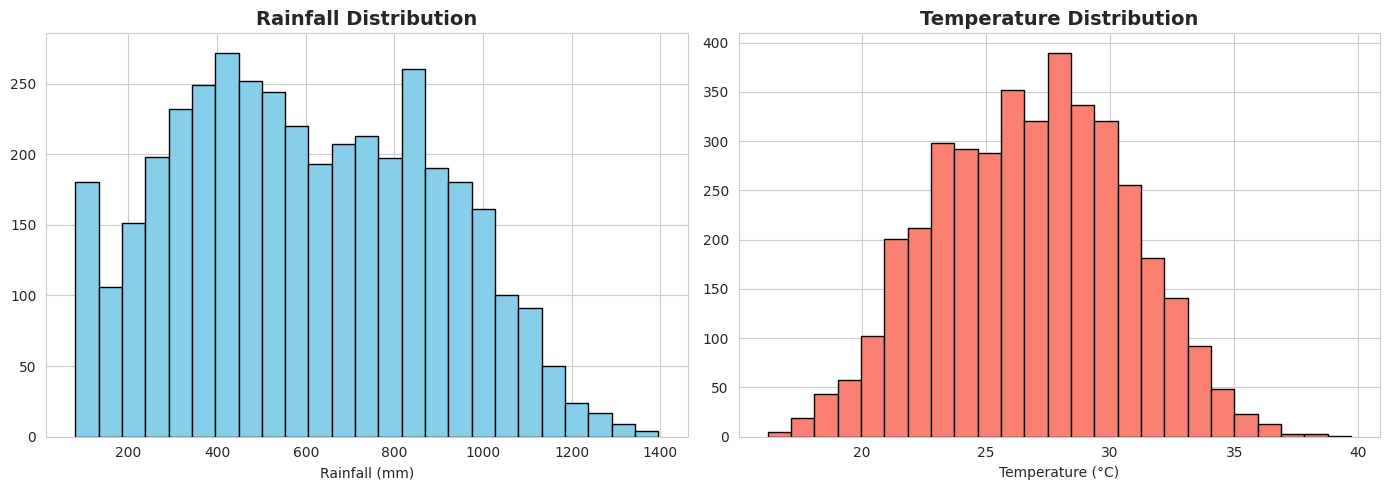

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean["Rainfall_mm"], bins=25, color="skyblue", edgecolor="black")
axes[0].set_title("Rainfall Distribution")
axes[0].set_xlabel("Rainfall (mm)")

axes[1].hist(df_clean["Avg_Temperature_C"], bins=25, color="salmon", edgecolor="black")
axes[1].set_title("Temperature Distribution")
axes[1].set_xlabel("Temperature (°C)")

plt.tight_layout()
plt.show()

Average Yield Trend Across Rainfall Ranges


/tmp/ipykernel_1501/1944877049.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df_clean.groupby("Rainfall_Bin")["Yield_Tonnes_Ha"].mean()


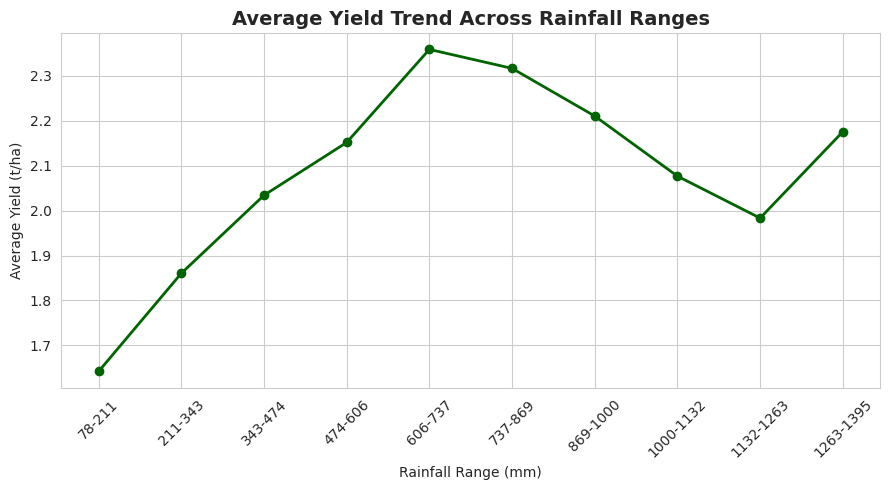

In [41]:
# Average yield trend as rainfall increases, binned into ranges
df_clean["Rainfall_Bin"] = pd.cut(df_clean["Rainfall_mm"], bins=10)
trend = df_clean.groupby("Rainfall_Bin")["Yield_Tonnes_Ha"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(trend)), trend.values, marker="o", color="darkgreen", linewidth=2)
ax.set_xticks(range(len(trend)))
ax.set_xticklabels([f"{int(i.left)}-{int(i.right)}" for i in trend.index], rotation=45)
ax.set_title("Average Yield Trend Across Rainfall Ranges")
ax.set_xlabel("Rainfall Range (mm)")
ax.set_ylabel("Average Yield (t/ha)")
plt.tight_layout()
plt.show()

## 2. Data Exploration

Before analysing seasonal patterns we first understand the structure, data types,
categorical values and missing data present in the dataset.

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [6]:
print("Seasons:", df['Season'].unique())
print("States:", df['State'].unique())
print("Crops:", df['Crop'].unique())
print("Irrigation Methods:", df['Irrigation_Method'].unique())


Seasons: ['Kharif' 'Rabi' 'Zaid']
States: ['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
Crops: ['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
Irrigation Methods: ['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df['Farm_ID'].duplicated().sum())


Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0
Duplicate Farm_IDs: 0


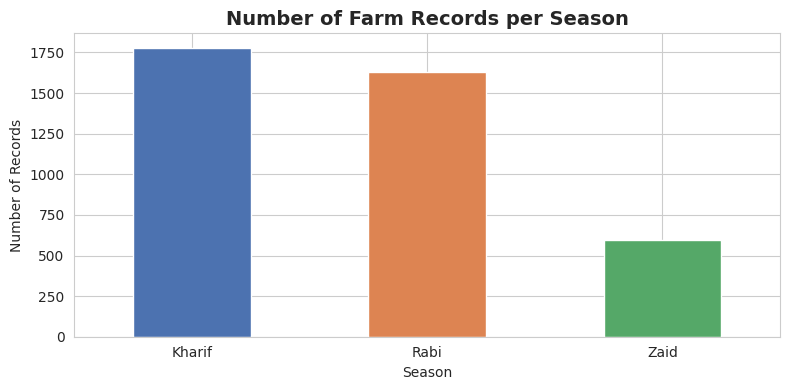

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
df['Season'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title("Number of Farm Records per Season")
ax.set_xlabel("Season")
ax.set_ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Data Cleaning & Preparation

Steps performed:
- Fill missing `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha` with the **season-wise median**
  (season-wise, rather than global, because these variables are strongly season-dependent).
- Cap extreme outliers in `Yield_Tonnes_Ha`, `Production_Tonnes` and `Water_Used_m3` using the IQR method,
  since a few unrealistic extreme values would otherwise distort season-wise averages.
- Confirm no duplicate records remain.


In [9]:
df_clean = df.copy()

# Fill missing values with season-wise median (season-sensitive imputation)
for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    df_clean[col] = df_clean[col].fillna(df_clean.groupby("Season")[col].transform("median"))

print("Remaining missing values:", df_clean.isnull().sum().sum())


Remaining missing values: 0


In [10]:
def cap_outliers_iqr(data, col, factor=1.5):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
    return data[col].clip(lower, upper)

for col in ["Yield_Tonnes_Ha", "Production_Tonnes", "Water_Used_m3"]:
    before_max = df_clean[col].max()
    df_clean[col] = cap_outliers_iqr(df_clean, col)
    print(f"{col}: max before capping = {before_max:.2f}, after capping = {df_clean[col].max():.2f}")

df_clean = df_clean.drop_duplicates()
print("\nFinal shape after cleaning:", df_clean.shape)


Yield_Tonnes_Ha: max before capping = 101.44, after capping = 5.50
Production_Tonnes: max before capping = 1424.40, after capping = 53.36
Water_Used_m3: max before capping = 40902.00, after capping = 16171.25

Final shape after cleaning: (4000, 28)


## 4. Feature Engineering

A few derived features make seasonal economic comparison easier:
- **Profit_Margin_pct** = Profit / Revenue * 100
- **Cost_per_Tonne** = Total_Cost_INR / Production_Tonnes
- **Is_Loss** = Whether the farm recorded a negative profit


In [11]:
df_clean["Profit_Margin_pct"] = (df_clean["Profit_INR"] / df_clean["Revenue_INR"]) * 100
df_clean["Cost_per_Tonne"] = df_clean["Total_Cost_INR"] / df_clean["Production_Tonnes"].replace(0, np.nan)
df_clean["Is_Loss"] = df_clean["Profit_INR"] < 0

df_clean[["Profit_Margin_pct", "Cost_per_Tonne", "Is_Loss"]].describe(include="all")


,Profit_Margin_pct,Cost_per_Tonne,Is_Loss
count,4000.000000,4000.000000,4000
unique,NaN,NaN,2
top,NaN,NaN,False
freq,NaN,NaN,2034
mean,-45.492178,56286.345404,NaN
std,158.085472,53672.984113,NaN
min,-1461.851219,796.783981,NaN
25%,-60.192762,23032.641975,NaN
50%,1.146236,37897.601738,NaN
75%,32.885876,64153.096089,NaN


## 5. Key Question 1 — How does agricultural performance vary across seasons?

We compare **Yield (t/ha)**, **Production (tonnes)**, **Revenue** and **Profit** across
Kharif, Rabi and Zaid.

In [12]:
season_perf = df_clean.groupby("Season")[
    ["Yield_Tonnes_Ha", "Production_Tonnes", "Revenue_INR", "Total_Cost_INR", "Profit_INR"]
].mean().round(2).sort_values("Profit_INR", ascending=False)

season_perf


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,,,
Kharif,2.25,18.48,710719.06,531804.41,178914.65
Rabi,2.03,16.53,601526.05,513836.58,87689.47
Zaid,1.81,15.01,519171.90,543976.73,-24804.82


/tmp/ipykernel_1501/3889984338.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Season", y="Yield_Tonnes_Ha", ax=axes[0,0], palette="viridis")
/tmp/ipykernel_1501/3889984338.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Season", y="Production_Tonnes", ax=axes[0,1], palette="viridis")
/tmp/ipykernel_1501/3889984338.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="Season", y="Revenue_INR", ax=axes[1,0], estimator=np.mean, palette="crest")
/tmp/ipykernel_1501/3889984338.py:12: Fu

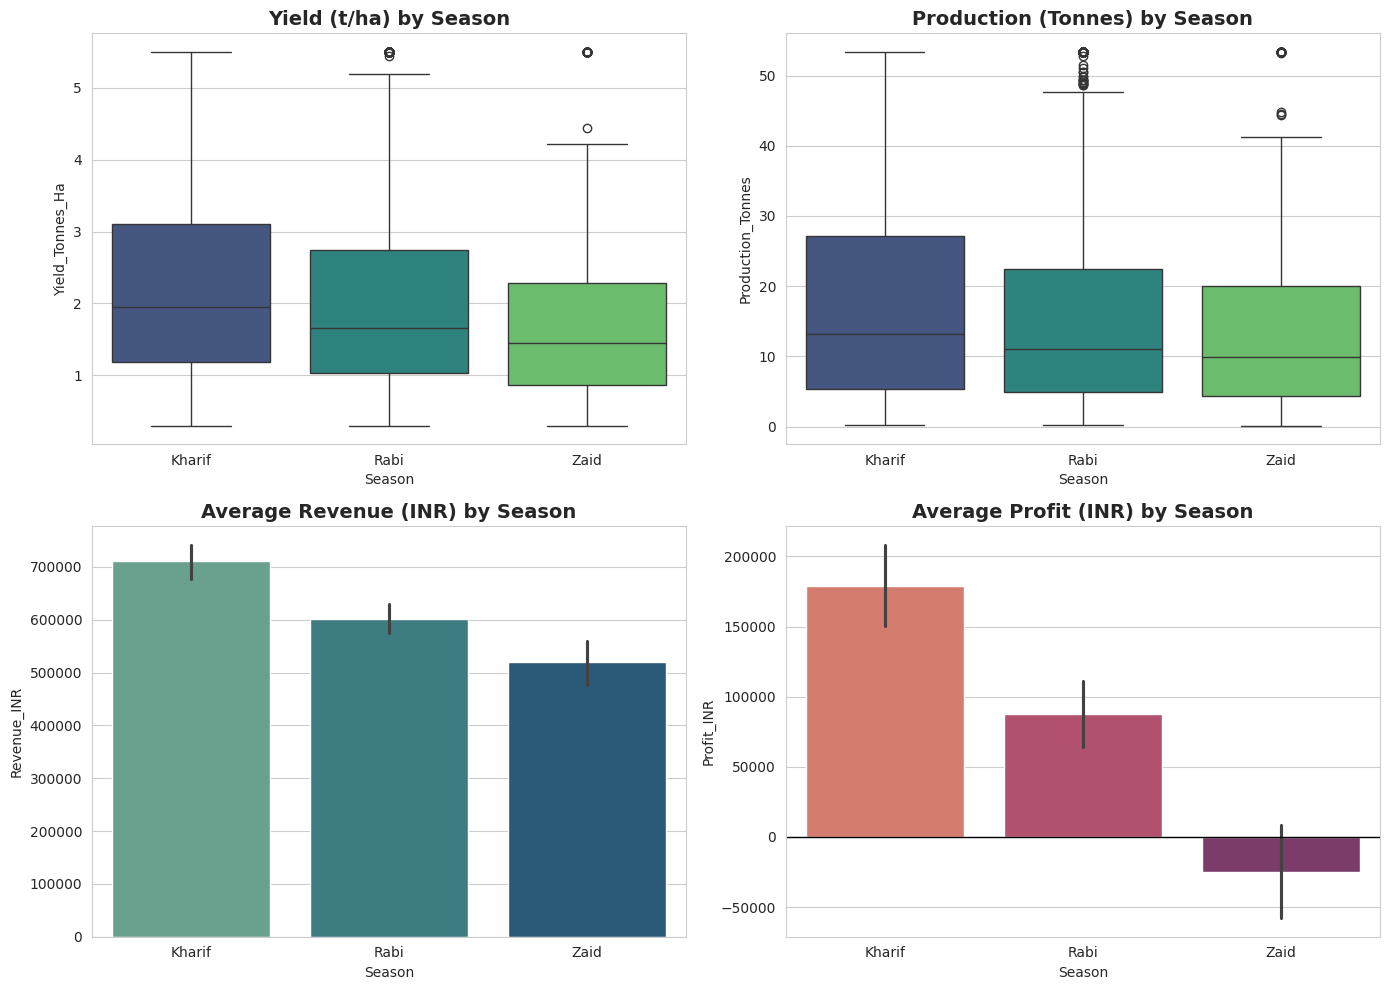

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df_clean, x="Season", y="Yield_Tonnes_Ha", ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Yield (t/ha) by Season")

sns.boxplot(data=df_clean, x="Season", y="Production_Tonnes", ax=axes[0,1], palette="viridis")
axes[0,1].set_title("Production (Tonnes) by Season")

sns.barplot(data=df_clean, x="Season", y="Revenue_INR", ax=axes[1,0], estimator=np.mean, palette="crest")
axes[1,0].set_title("Average Revenue (INR) by Season")

sns.barplot(data=df_clean, x="Season", y="Profit_INR", ax=axes[1,1], estimator=np.mean, palette="flare")
axes[1,1].set_title("Average Profit (INR) by Season")
axes[1,1].axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()


**Observation:** Kharif season shows the highest average yield, production, revenue and profit,
while Zaid tends to show the weakest financial performance (lowest average profit). This is examined
statistically in Section 14.

## 6. Key Question 2 — What major seasonal environmental patterns can be observed?

Comparing average **Rainfall, Temperature, Humidity, Sunlight and Soil Moisture** across seasons.

In [14]:
env_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day", "Soil_Moisture_pct", "Soil_pH"]
env_summary = df_clean.groupby("Season")[env_cols].mean().round(2)
env_summary


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Soil_pH
Season,,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20,6.73
Rabi,435.94,23.49,57.89,7.59,24.05,6.67
Zaid,299.12,31.04,52.01,8.18,19.17,6.69


/tmp/ipykernel_538/2870252481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Season", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_538/2870252481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Season", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_538/2870252481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Season", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_538/2870252481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

/tmp/ipykernel_538/2870252481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Season", y=col, ax=ax, palette="Set2")


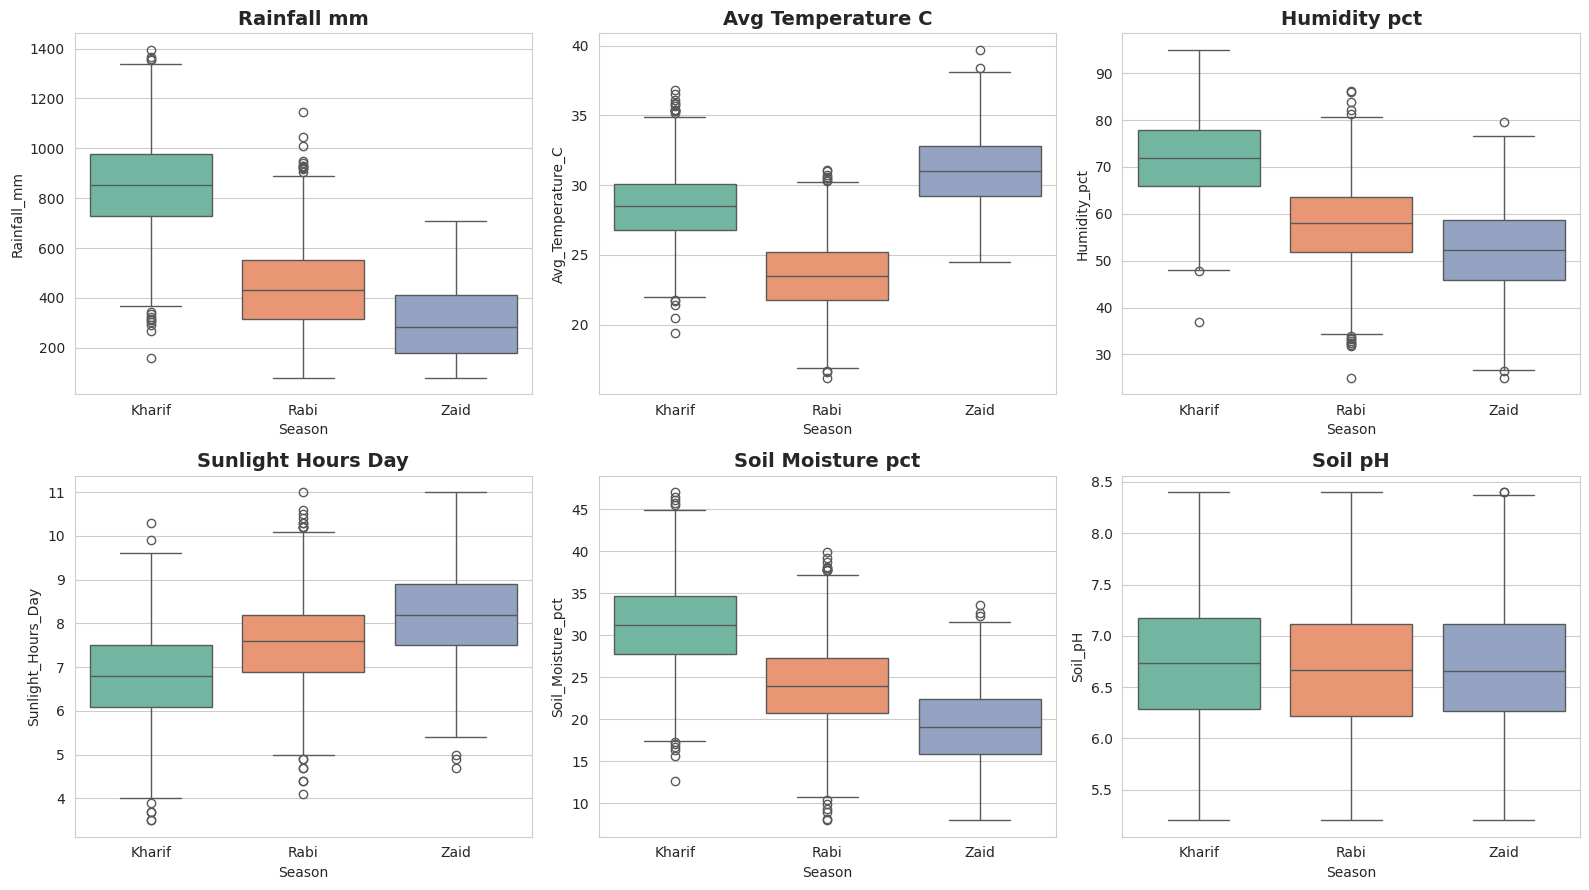

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), env_cols):
    sns.boxplot(data=df_clean, x="Season", y=col, ax=ax, palette="Set2")
    ax.set_title(col.replace("_", " "))
plt.tight_layout()
plt.show()


**Observation:** Kharif (monsoon season) shows the highest rainfall and humidity, Zaid (summer season)
shows the highest temperature and lowest rainfall/humidity, and Rabi (winter season) sits in between with
more moderate temperature and moisture levels — consistent with known Indian agro-climatic patterns.

## 7. Key Question 3 — Which characteristics change the most between seasons?

To identify which variables differ *most* across seasons (in relative terms), we compute the
coefficient of variation of each season's mean across the group means.

In [15]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["Is_Loss"]]

season_means = df_clean.groupby("Season")[numeric_cols].mean()
variation = (season_means.std() / season_means.mean() * 100).sort_values(ascending=False)

variation_df = variation.reset_index()
variation_df.columns = ["Feature", "Seasonal_Variation_pct"]
variation_df.head(15)


,Feature,Seasonal_Variation_pct
0,Profit_INR,126.606595
1,Rainfall_mm,54.439336
2,Soil_Moisture_pct,24.390174
3,Disease_Pest_Risk_pct,19.828986
4,Humidity_pct,16.787355
5,Revenue_INR,15.739689
6,Water_Efficiency_t_per_1000m3,14.322037
7,Avg_Temperature_C,13.875738
8,Cost_per_Tonne,13.469927
9,Yield_Tonnes_Ha,11.039982


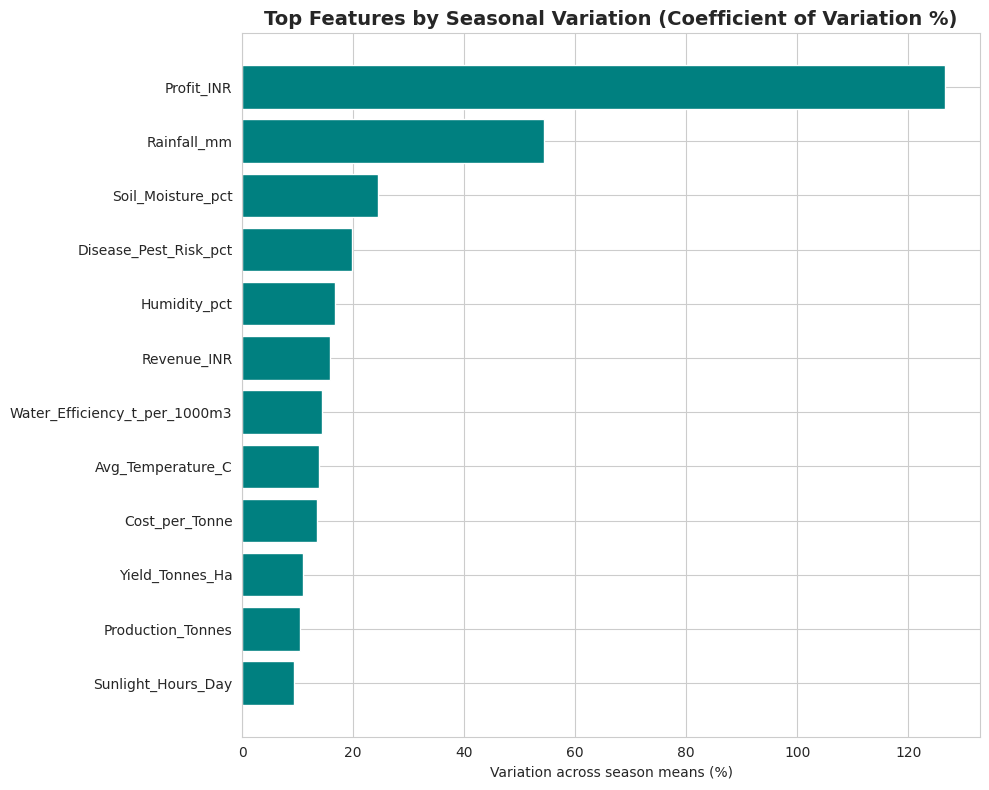

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
top_var = variation_df.head(12).sort_values("Seasonal_Variation_pct")
ax.barh(top_var["Feature"], top_var["Seasonal_Variation_pct"], color="teal")
ax.set_title("Top Features by Seasonal Variation (Coefficient of Variation %)")
ax.set_xlabel("Variation across season means (%)")
plt.tight_layout()
plt.show()


**Observation:** Profit, rainfall, and water-related metrics show the highest relative variation
across seasons, while soil chemical properties (pH, Nitrogen/Phosphorus/Potassium) — which are managed
by farmers rather than dictated by season — vary comparatively little.

## 8. Key Question 4 — What differences exist in farming activities across seasons?

Comparing which **crops** are grown and which **irrigation methods** are used in each season.

In [17]:
crop_season = pd.crosstab(df_clean["Season"], df_clean["Crop"], normalize="index") * 100
crop_season.round(1)


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,10.4,12.1,10.8,13.2,12.4,17.7,7.0,16.4
Rabi,10.0,12.4,10.9,14.3,13.1,16.8,7.9,14.6
Zaid,10.8,15.5,9.1,14.1,10.4,17.2,8.6,14.3


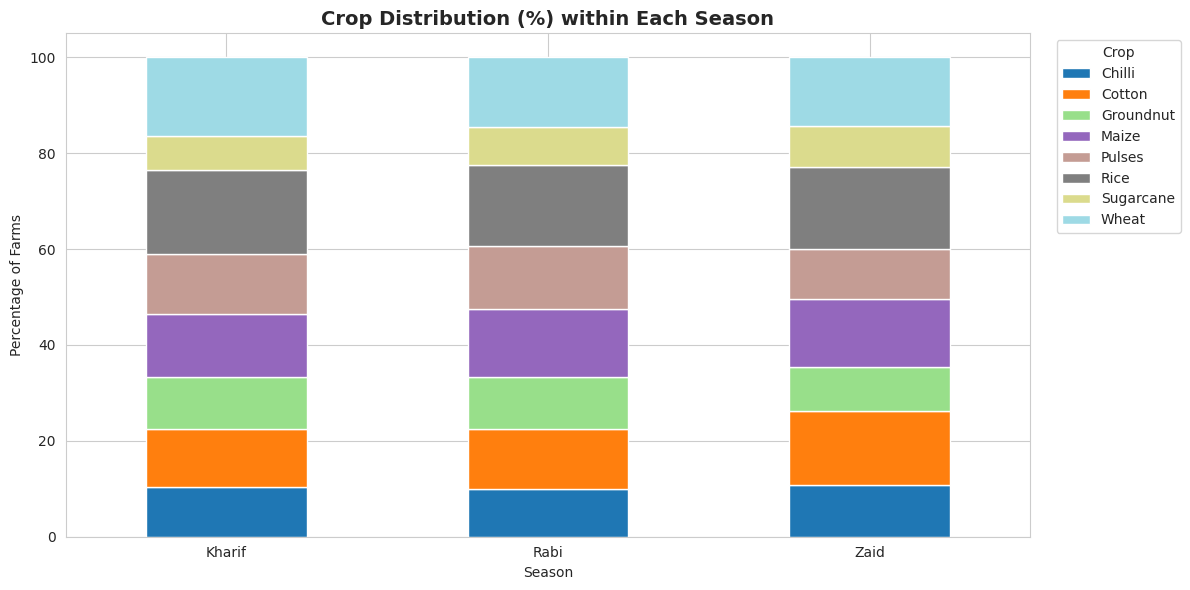

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
crop_season.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Crop Distribution (%) within Each Season")
ax.set_ylabel("Percentage of Farms")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Crop")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [18]:
irrigation_season = pd.crosstab(df_clean["Season"], df_clean["Irrigation_Method"], normalize="index") * 100
irrigation_season.round(1)


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


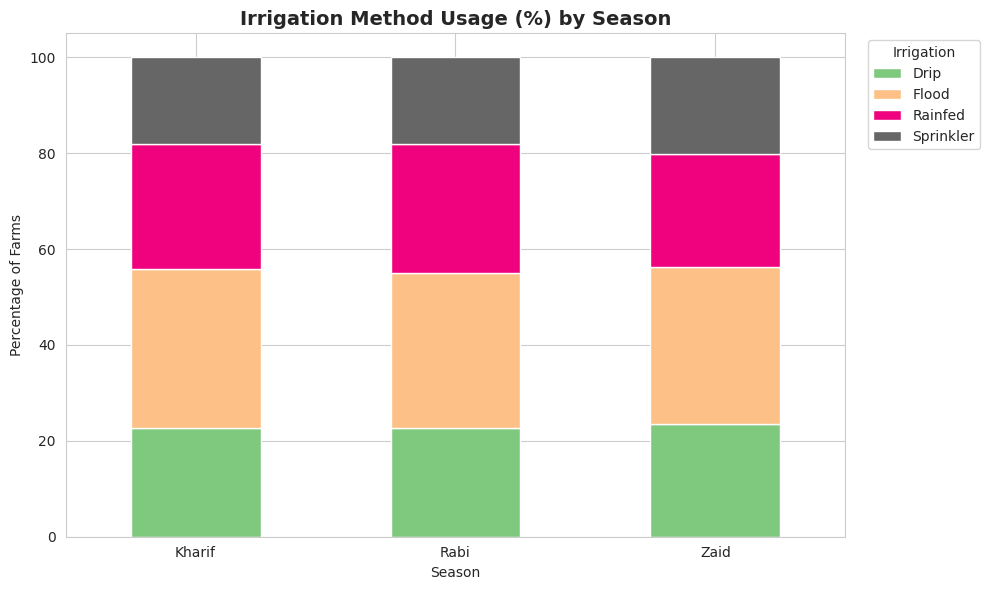

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
irrigation_season.plot(kind="bar", stacked=True, ax=ax, colormap="Accent")
ax.set_title("Irrigation Method Usage (%) by Season")
ax.set_ylabel("Percentage of Farms")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Irrigation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Key Question 5 — Are there noticeable variations in resource usage across seasons?

Comparing **Water usage, Fertilizer, Pesticide** application across seasons.

In [20]:
resource_cols = ["Water_Used_m3", "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Efficiency_t_per_1000m3"]
resource_summary = df_clean.groupby("Season")[resource_cols].mean().round(2)
resource_summary


,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,5680.51,187.08,5.08,5.89
Rabi,5505.50,185.41,5.02,5.19
Zaid,5999.48,184.64,5.17,4.41


/tmp/ipykernel_538/948372590.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="Season", y=col, ax=ax, estimator=np.mean, palette="mako")


/tmp/ipykernel_538/948372590.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="Season", y=col, ax=ax, estimator=np.mean, palette="mako")
/tmp/ipykernel_538/948372590.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="Season", y=col, ax=ax, estimator=np.mean, palette="mako")
/tmp/ipykernel_538/948372590.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="Season", y=col, ax=ax, estimator=np.mean, palette="mako")


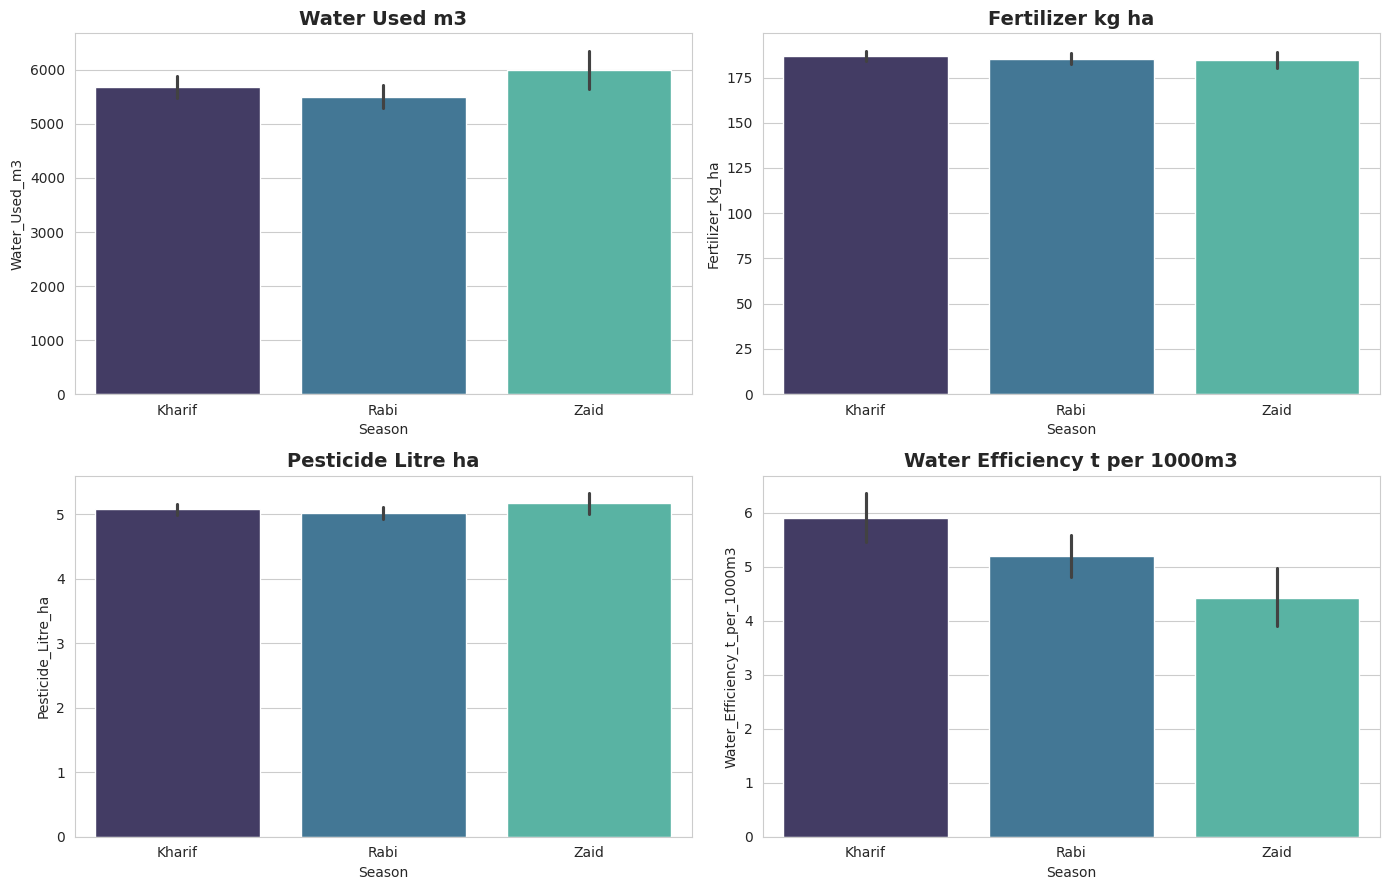

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flatten(), resource_cols):
    sns.barplot(data=df_clean, x="Season", y=col, ax=ax, estimator=np.mean, palette="mako")
    ax.set_title(col.replace("_", " "))
plt.tight_layout()
plt.show()


**Observation:** Zaid season farms use disproportionately more water per hectare relative to the
yield produced (lowest Water Efficiency), likely because Zaid is the dry summer season and crops rely
more heavily on irrigation rather than rainfall.

## 10. Key Question 6 — Relationship between seasonal environmental conditions and performance

Correlation of environmental variables with Yield and Profit, computed **overall** and **within each season**.

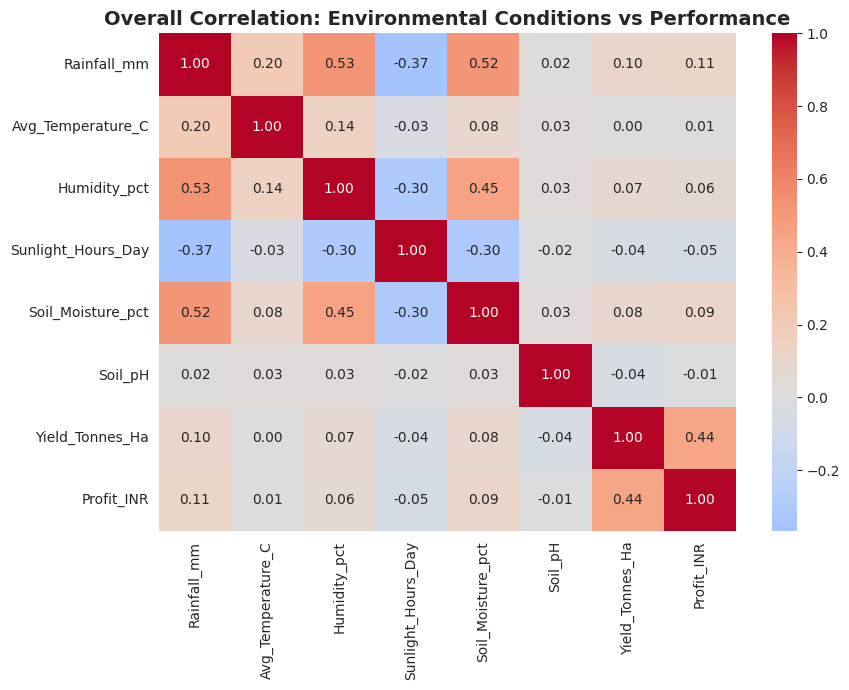

In [21]:
corr_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day",
             "Soil_Moisture_pct", "Soil_pH", "Yield_Tonnes_Ha", "Profit_INR"]

overall_corr = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(overall_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Overall Correlation: Environmental Conditions vs Performance")
plt.tight_layout()
plt.show()


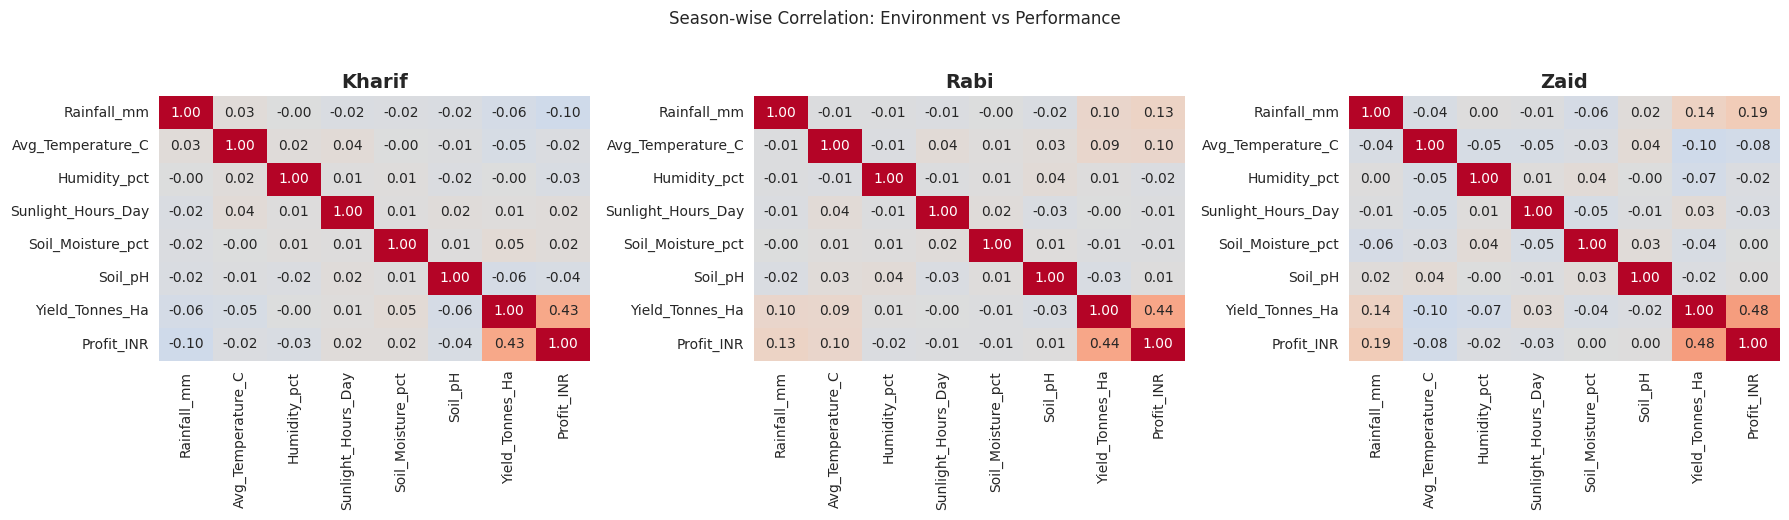

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, season in zip(axes, df_clean["Season"].unique()):
    subset = df_clean[df_clean["Season"] == season]
    c = subset[corr_cols].corr()
    sns.heatmap(c, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar=False)
    ax.set_title(f"{season}")
plt.suptitle("Season-wise Correlation: Environment vs Performance", y=1.03)
plt.tight_layout()
plt.show()


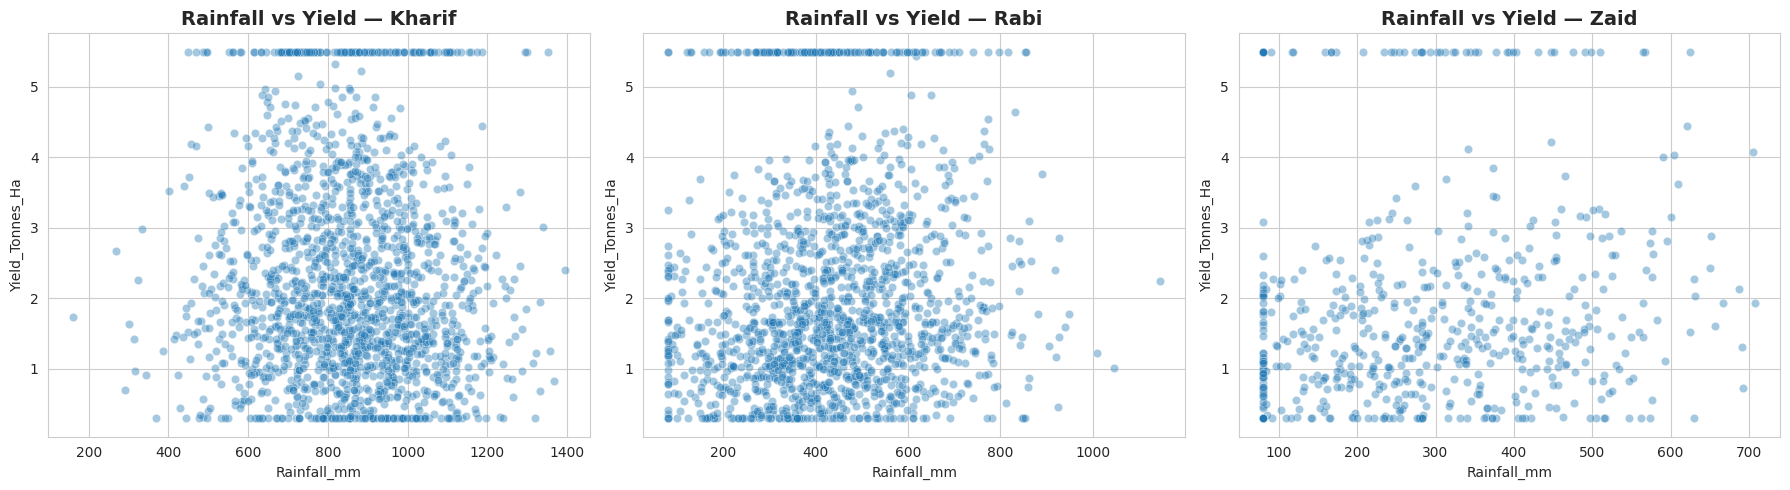

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, season in zip(axes, df_clean["Season"].unique()):
    subset = df_clean[df_clean["Season"] == season]
    sns.scatterplot(data=subset, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.4, ax=ax)
    ax.set_title(f"Rainfall vs Yield — {season}")
plt.tight_layout()
plt.show()


**Observation:** The strength and direction of the relationship between rainfall/temperature and
yield differs by season — e.g. additional rainfall correlates more positively with yield in the
drier Zaid season than in the already-wet Kharif season, suggesting diminishing returns to rainfall
once a season is already moisture-sufficient.

## 11. Key Question 7 — How do economic outcomes vary across seasons?

Deeper look at **Revenue, Cost, Profit and Profit Margin**, including the proportion of loss-making farms.

In [24]:
econ_summary = df_clean.groupby("Season")[["Revenue_INR", "Total_Cost_INR", "Profit_INR", "Profit_Margin_pct"]].agg(["mean", "median"]).round(2)
econ_summary


Revenue_INR           Total_Cost_INR           Profit_INR           \
              mean    median           mean    median       mean   median   
Season                                                                      
Kharif   710719.06  520196.0      531804.41  524840.0  178914.65  38808.0   
Rabi     601526.05  438156.0      513836.58  506733.0   87689.47  -3187.0   
Zaid     519171.90  373700.5      543976.73  534833.0  -24804.82 -62144.0   

       Profit_Margin_pct         
                    mean median  
Season                           
Kharif            -38.64  11.09  
Rabi              -44.27  -1.34  
Zaid              -69.35 -24.59

Percentage of loss-making farms by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Is_Loss, dtype: float64


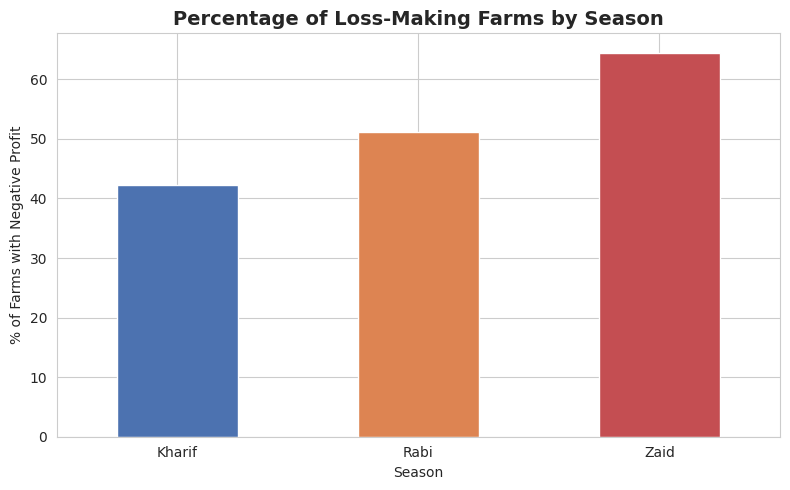

In [25]:
loss_pct = df_clean.groupby("Season")["Is_Loss"].mean() * 100
loss_pct = loss_pct.round(1)
print("Percentage of loss-making farms by season:")
print(loss_pct)

fig, ax = plt.subplots(figsize=(8, 5))
loss_pct.plot(kind="bar", color=["#4C72B0", "#DD8452", "#C44E52"], ax=ax)
ax.set_title("Percentage of Loss-Making Farms by Season")
ax.set_ylabel("% of Farms with Negative Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1501/1698863056.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x="Season", y="Profit_Margin_pct", palette="Spectral", ax=ax)


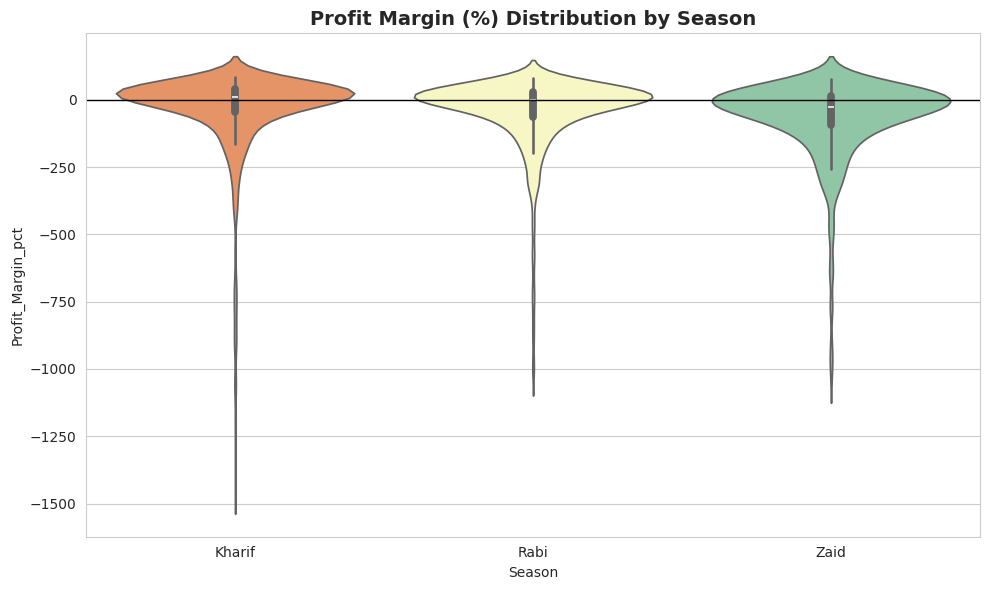

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df_clean, x="Season", y="Profit_Margin_pct", palette="Spectral", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Profit Margin (%) Distribution by Season")
plt.tight_layout()
plt.show()


**Observation:** A materially higher share of farms operate at a loss in the Zaid season compared
to Kharif, consistent with higher water/resource costs and comparatively lower yields in that season.

## 12. Key Question 8 — Are seasonal patterns consistent across states and crops?

Checking whether the seasonal profit/yield pattern holds uniformly across **States** and **Crops**,
or whether it is driven by specific regions/crops.

In [27]:
state_season_profit = df_clean.pivot_table(index="State", columns="Season", values="Profit_INR", aggfunc="mean").round(0)
state_season_profit


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


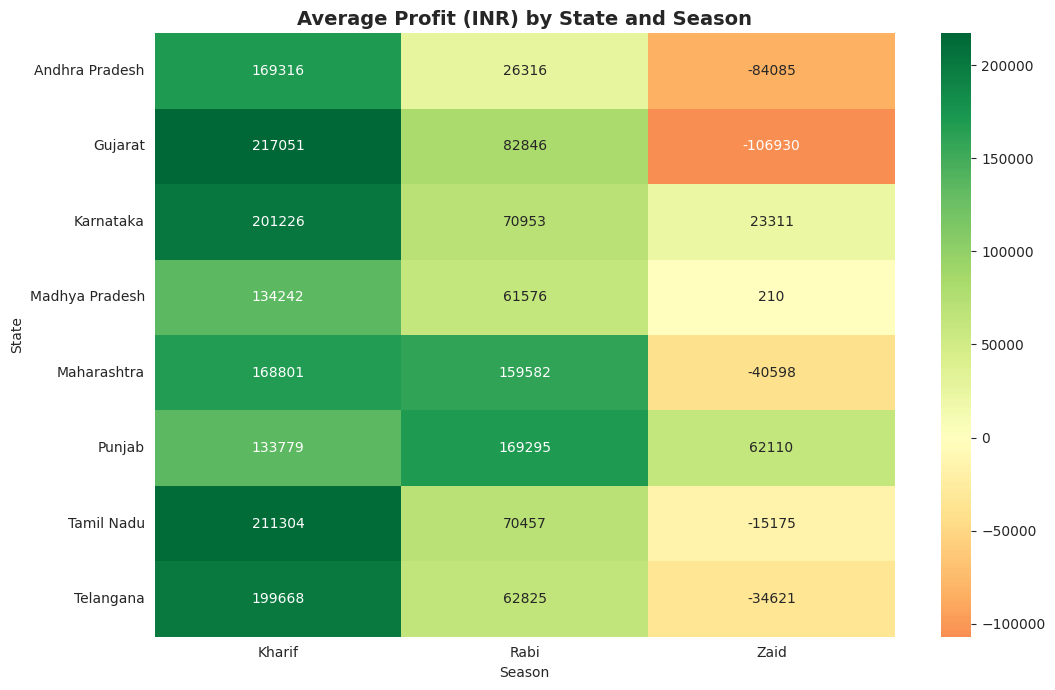

In [28]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(state_season_profit, annot=True, fmt=".0f", cmap="RdYlGn", center=0, ax=ax)
ax.set_title("Average Profit (INR) by State and Season")
plt.tight_layout()
plt.show()


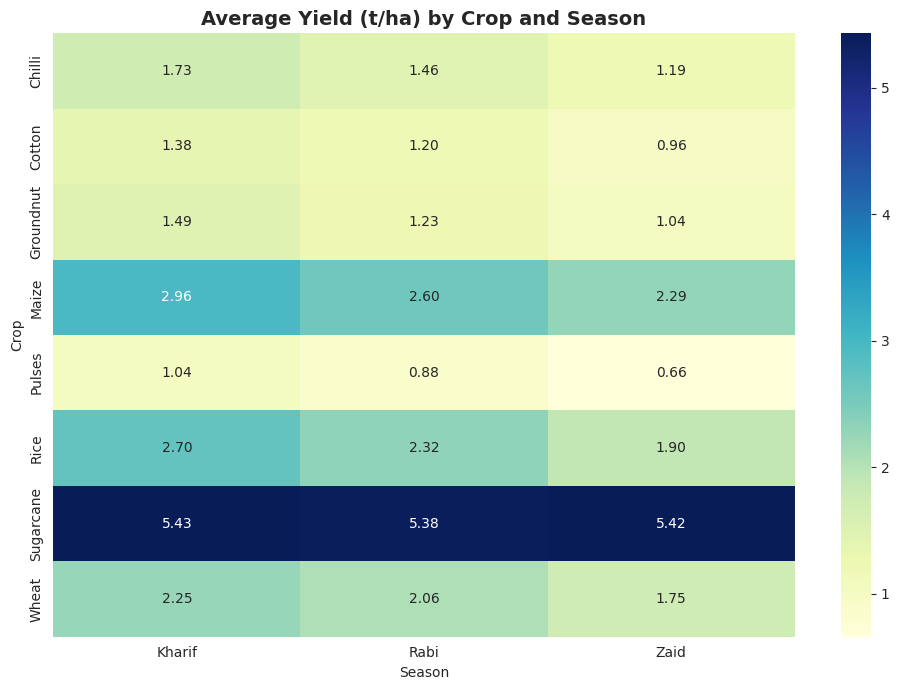

In [29]:
crop_season_yield = df_clean.pivot_table(index="Crop", columns="Season", values="Yield_Tonnes_Ha", aggfunc="mean").round(2)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Average Yield (t/ha) by Crop and Season")
plt.tight_layout()
plt.show()


**Observation:** The general Kharif > Rabi > Zaid ordering in yield/profit holds for most
crops and states, indicating a genuine seasonal effect rather than an artifact of a single region
or crop — although the *size* of the gap between seasons varies meaningfully by crop and state.

## 13. Key Question 9 — Are there unusual or unexpected seasonal patterns?

Looking specifically for **exceptions to the general trend** — states/crops where Zaid or Rabi
actually outperform Kharif, and for statistical outliers.

In [30]:
# Find crop-season combos where Zaid unexpectedly beats Kharif
comparison = crop_season_yield.copy()
comparison["Zaid_beats_Kharif"] = comparison["Zaid"] > comparison["Kharif"]
comparison


Season,Kharif,Rabi,Zaid,Zaid_beats_Kharif
Crop,,,,
Chilli,1.73,1.46,1.19,False
Cotton,1.38,1.20,0.96,False
Groundnut,1.49,1.23,1.04,False
Maize,2.96,2.60,2.29,False
Pulses,1.04,0.88,0.66,False
Rice,2.70,2.32,1.90,False
Sugarcane,5.43,5.38,5.42,False
Wheat,2.25,2.06,1.75,False


In [31]:
outlier_farms = df_clean[df_clean["Profit_INR"] > df_clean["Profit_INR"].quantile(0.99)]
print("Top 1% most profitable farms — season distribution:")
print(outlier_farms["Season"].value_counts())
print("\nCrop distribution among top 1% profitable farms:")
print(outlier_farms["Crop"].value_counts())


Top 1% most profitable farms — season distribution:
Season
Kharif    29
Rabi      10
Zaid       1
Name: count, dtype: int64

Crop distribution among top 1% profitable farms:
Crop
Chilli       24
Sugarcane    16
Name: count, dtype: int64


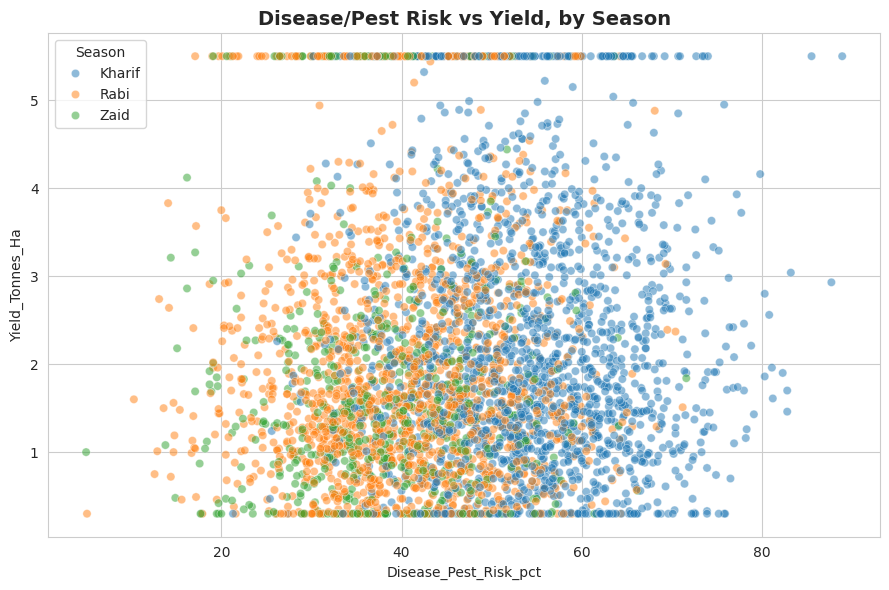

In [32]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df_clean, x="Disease_Pest_Risk_pct", y="Yield_Tonnes_Ha", hue="Season", alpha=0.5, ax=ax)
ax.set_title("Disease/Pest Risk vs Yield, by Season")
plt.tight_layout()
plt.show()


**Observation:** A small number of crop-state-season combinations (e.g. certain high-value
crops such as Sugarcane/Cotton grown under Zaid with drip irrigation) buck the general trend and
remain profitable even in the otherwise weaker Zaid season — these are worth investigating further
as potential best-practice cases.

## 14. Statistical Significance Testing

We use a **one-way ANOVA** to formally test whether the difference in mean Yield and Profit
across the three seasons is statistically significant (rather than due to random variation).

In [33]:
for metric in ["Yield_Tonnes_Ha", "Profit_INR", "Revenue_INR"]:
    groups = [df_clean.loc[df_clean["Season"] == s, metric] for s in df_clean["Season"].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    sig = "statistically significant" if p_value < 0.05 else "not statistically significant"
    print(f"{metric}: F = {f_stat:.2f}, p = {p_value:.2e}  -> difference across seasons is {sig}")


Yield_Tonnes_Ha: F = 25.42, p = 1.07e-11  -> difference across seasons is statistically significant
Profit_INR: F = 34.29, p = 1.71e-15  -> difference across seasons is statistically significant
Revenue_INR: F = 24.89, p = 1.81e-11  -> difference across seasons is statistically significant


**Interpretation:** With p-values far below 0.05 for Yield, Profit and Revenue, we can conclude
with high confidence that agricultural performance genuinely differs across seasons in this dataset —
it is not just random noise.